# Defect Detection QML Experiment Notebook

This notebook is a scratchpad for trying classical and quantum classifiers on the synthetic defect images generated by `util/defect_gen.py`.

The generated images are small grayscale arrays. The label convention is:

- `0`: clean / normal image
- `1`: defective image

The main practical issue is that an `8x8` image has `64` raw pixel features. A direct quantum circuit with 64 feature qubits would be too large for quick iteration, so the quantum sections reduce the image vectors with PCA before encoding them into quantum circuits.

## 1. Imports and Local Paths

This cell makes sure the notebook can import `defect_gen.py` from the nearby `util` folder even if VS Code starts the notebook from the project root.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, balanced_accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC

from qiskit.circuit.library import n_local, zz_feature_map
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms.optimizers import COBYLA, SPSA
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.neural_networks import SamplerQNN

# Resolve the util folder robustly from either the repo root or this notebook folder.
UTIL_DIR = Path("notebooks/iqucodefest-2026-main/main_challenge/util")
if not UTIL_DIR.exists():
    UTIL_DIR = Path.cwd() / "util"
UTIL_DIR = UTIL_DIR.resolve()

if str(UTIL_DIR) not in sys.path:
    sys.path.insert(0, str(UTIL_DIR))

from defect_gen import generate_dataset, show_samples

SEED = 8398
np.random.seed(SEED)

print(f"Using defect generator from: {UTIL_DIR}")

Using defect generator from: /Users/bren/Desktop/Phys 622 Quantum Computing Essentials/Hackathon/notebooks/iqucodefest-2026-main/main_challenge/util


## 2. Generate a Dataset

The defect generator creates mid-gray normal images and inserts one near-black blob into defective samples. Start with a slightly higher `defect_rate` while experimenting so the classifiers see enough defective examples. Later, reduce it to the real challenge setting if needed.

In [2]:
N_SAMPLES = 200
IMAGE_SIZE = 8
DEFECT_RATE = 0.20

images, labels = generate_dataset(
    n_samples=N_SAMPLES,
    size=IMAGE_SIZE,
    defect_rate=DEFECT_RATE,
    normal_range=(0.3, 0.5),
    defect_range=(0.95, 0.99),
    seed=SEED,
)

print("images shape:", images.shape)
print("labels shape:", labels.shape)
print("defect fraction:", labels.mean())

### Dataset generation complete ###
Total samples: 200
Image size: 8x8
Number of normal images: 160
Number of defective images: 40
### ### ###  ### ### ### ### ### ### ### ### ###

images shape: (200, 8, 8)
labels shape: (200,)
defect fraction: 0.2


## 3. Visual Check

Always look at generated data before training. If the defect is too visually obvious or too rare, model performance can be misleading.

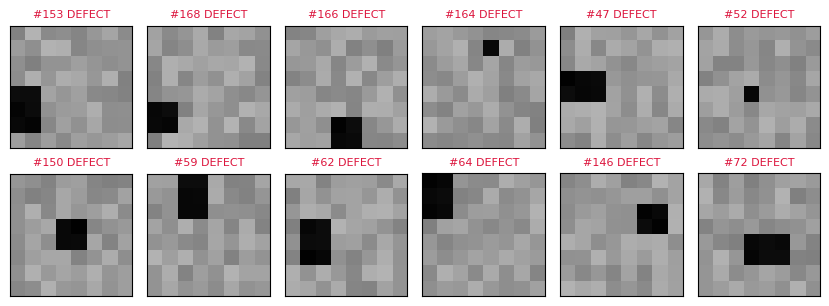

In [3]:
show_samples(images, labels, n_show=12, cols=6)

## 4. Train/Test Split

Each image is flattened from `(8, 8)` to `64` raw pixel features. We use a stratified split so the train and test sets keep the same clean/defect ratio.

In [5]:
X = images.reshape(len(images), -1)
y = labels

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED,
    stratify=y,
)

print("train:", X_train.shape, "clean:", (y_train == 0).sum(), "defect:", (y_train == 1).sum())
print("test :", X_test.shape, "clean:", (y_test == 0).sum(), "defect:", (y_test == 1).sum())

train: (150, 64) clean: 120 defect: 30
test : (50, 64) clean: 40 defect: 10


## 5. Shared Evaluation Helpers

Accuracy alone can hide bad behavior when defects are rare. `balanced_accuracy` and defect-class F1 are better quick checks.

In [6]:
def evaluate_classifier(name, model, X_eval, y_eval, *, show_confusion=True):
    """Print useful metrics for binary defect detection."""
    y_pred = model.predict(X_eval)
    print(f"\n{name}")
    print("balanced accuracy:", balanced_accuracy_score(y_eval, y_pred))
    print("defect F1 score  :", f1_score(y_eval, y_pred, zero_division=0))
    print(classification_report(y_eval, y_pred, target_names=["clean", "defect"], zero_division=0))

    if show_confusion:
        ConfusionMatrixDisplay.from_predictions(y_eval, y_pred, display_labels=["clean", "defect"])
        plt.title(name)
        plt.show()


def balanced_subset(X_data, y_data, n_per_class=12, seed=SEED):
    """Make a small balanced set for slower quantum training experiments."""
    rng = np.random.default_rng(seed)
    chosen = []

    for cls in np.unique(y_data):
        cls_idx = np.flatnonzero(y_data == cls)
        take = min(n_per_class, len(cls_idx))
        chosen.extend(rng.choice(cls_idx, size=take, replace=False).tolist())

    rng.shuffle(chosen)
    return X_data[chosen], y_data[chosen]

## 6. Classical Baselines

These are not the final quantum answer, but they are important sanity checks. If a simple classical model works extremely well, the synthetic dataset may be too easy. If every classical model fails, the features or labels may need inspection.

In [7]:
classical_models = {
    "Logistic Regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED)),
    ]),
    "RBF SVM": Pipeline([
        ("scale", StandardScaler()),
        ("model", SVC(kernel="rbf", class_weight="balanced", random_state=SEED)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=SEED,
    ),
}

for name, model in classical_models.items():
    model.fit(X_train, y_train)
    evaluate_classifier(name, model, X_test, y_test, show_confusion=False)


Logistic Regression
balanced accuracy: 0.9125000000000001
defect F1 score  : 0.8181818181818182
              precision    recall  f1-score   support

       clean       0.97      0.93      0.95        40
      defect       0.75      0.90      0.82        10

    accuracy                           0.92        50
   macro avg       0.86      0.91      0.88        50
weighted avg       0.93      0.92      0.92        50


RBF SVM
balanced accuracy: 1.0
defect F1 score  : 1.0
              precision    recall  f1-score   support

       clean       1.00      1.00      1.00        40
      defect       1.00      1.00      1.00        10

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50


Random Forest
balanced accuracy: 0.5
defect F1 score  : 0.0
              precision    recall  f1-score   support

       clean       0.80      1.00      0.89        40
      defect       0.00 

## 7. Quantum Feature Preparation

Quantum circuits need a small number of input features. This cell creates two versions of the data:

- `X_*_pca`: PCA features for inspection or classical comparison.
- `X_*_q`: PCA features scaled to `[0, pi]`, suitable for angle-style quantum feature maps.

Change `N_QUBITS` to try a larger or smaller quantum circuit. Larger values can become slow quickly.

In [9]:
N_QUBITS = 4

pixel_scaler = StandardScaler()
X_train_scaled = pixel_scaler.fit_transform(X_train)
X_test_scaled = pixel_scaler.transform(X_test)

pca = PCA(n_components=N_QUBITS, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Quantum feature maps usually expect bounded angles. [0, pi] is a simple default.
angle_scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_q = angle_scaler.fit_transform(X_train_pca)
X_test_q = angle_scaler.transform(X_test_pca)

print("PCA explained variance:", np.round(pca.explained_variance_ratio_, 3))
print("Total explained variance:", round(float(pca.explained_variance_ratio_.sum()), 3))
print("Quantum train shape:", X_train_q.shape)

PCA explained variance: [0.065 0.059 0.056 0.051]
Total explained variance: 0.231
Quantum train shape: (150, 4)


## 8. PCA-Space Classical SVM

This baseline uses the exact reduced features that the quantum methods see. It helps answer: is the quantum method helping, or did PCA already solve the problem?


PCA-space RBF SVM
balanced accuracy: 0.95
defect F1 score  : 0.9473684210526315
              precision    recall  f1-score   support

       clean       0.98      1.00      0.99        40
      defect       1.00      0.90      0.95        10

    accuracy                           0.98        50
   macro avg       0.99      0.95      0.97        50
weighted avg       0.98      0.98      0.98        50



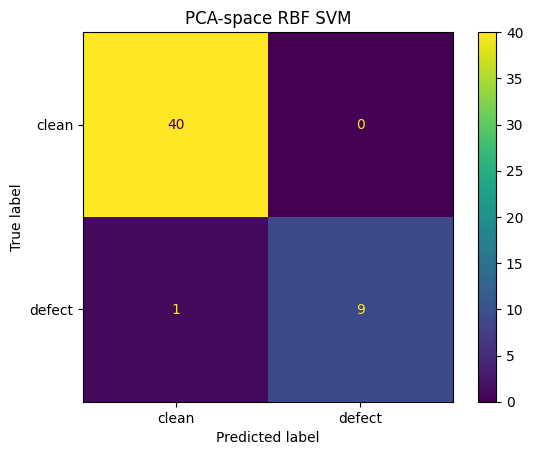

In [10]:
pca_svm = SVC(kernel="rbf", class_weight="balanced", random_state=SEED)
pca_svm.fit(X_train_q, y_train)
evaluate_classifier("PCA-space RBF SVM", pca_svm, X_test_q, y_test)

## 9. Quantum Kernel Classifier (`QSVC`)

`QSVC` is a support-vector classifier where the kernel matrix is computed from a quantum feature map. This is often one of the easiest quantum ML baselines to try before training a variational QNN.

The kernel calculation scales with the number of samples, so this cell optionally trains on a smaller balanced subset.


Quantum Kernel QSVC
balanced accuracy: 0.95
defect F1 score  : 0.9032258064516129
              precision    recall  f1-score   support

       clean       0.98      0.97      0.97       120
      defect       0.88      0.93      0.90        30

    accuracy                           0.96       150
   macro avg       0.93      0.95      0.94       150
weighted avg       0.96      0.96      0.96       150



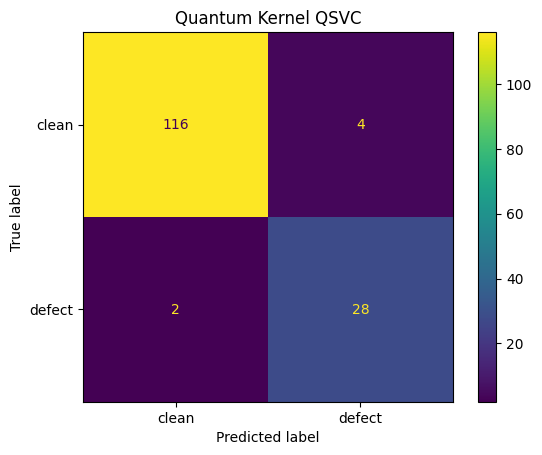


Quantum Kernel QSVC
balanced accuracy: 0.9125000000000001
defect F1 score  : 0.8181818181818182
              precision    recall  f1-score   support

       clean       0.97      0.93      0.95        40
      defect       0.75      0.90      0.82        10

    accuracy                           0.92        50
   macro avg       0.86      0.91      0.88        50
weighted avg       0.93      0.92      0.92        50



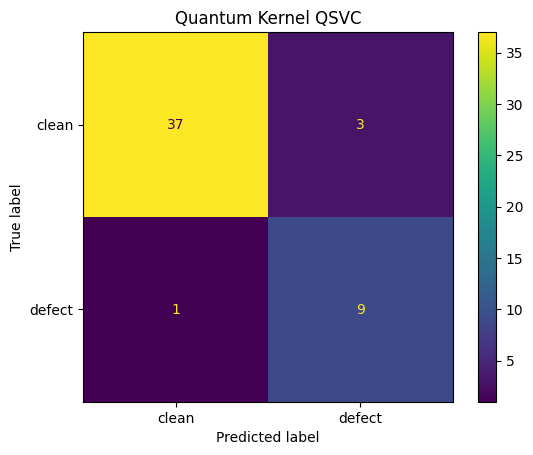

In [13]:
KERNEL_TRAIN_PER_CLASS = 25

X_kernel_train, y_kernel_train = balanced_subset(
    X_train_q,
    y_train,
    n_per_class=KERNEL_TRAIN_PER_CLASS,
)

feature_map = zz_feature_map(feature_dimension=N_QUBITS, reps=1)
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

qsvc = QSVC(quantum_kernel=quantum_kernel, class_weight="balanced")
qsvc.fit(X_kernel_train, y_kernel_train)

evaluate_classifier("Quantum Kernel QSVC", qsvc, X_train_q, y_train)
evaluate_classifier("Quantum Kernel QSVC", qsvc, X_test_q, y_test)

## 10. Variational QNN Classifier (`SamplerQNN`)

This is the closest match to the side-quest QML protocol: a feature map embeds the input data, an ansatz provides trainable parameters, and `NeuralNetworkClassifier` runs the classical optimization loop.

Use a small balanced training subset at first. If the cell runs and the metrics are promising, increase `QNN_TRAIN_PER_CLASS`, `QNN_MAXITER`, or `N_QUBITS`.

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.



SamplerQNN classifier
balanced accuracy: 0.6333333333333333
defect F1 score  : 0.41025641025641024
              precision    recall  f1-score   support

       clean       0.86      0.73      0.79       120
      defect       0.33      0.53      0.41        30

    accuracy                           0.69       150
   macro avg       0.60      0.63      0.60       150
weighted avg       0.76      0.69      0.72       150



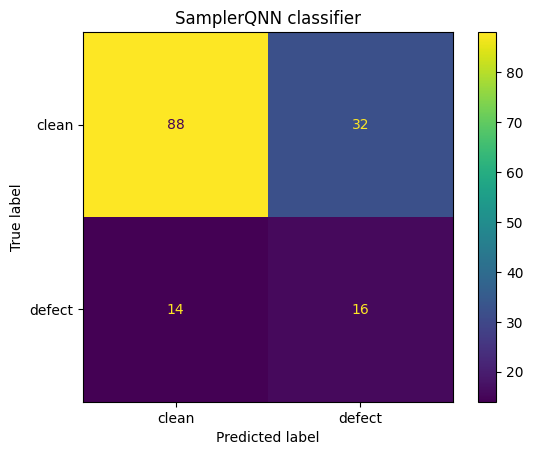


SamplerQNN classifier
balanced accuracy: 0.7
defect F1 score  : 0.4827586206896552
              precision    recall  f1-score   support

       clean       0.90      0.70      0.79        40
      defect       0.37      0.70      0.48        10

    accuracy                           0.70        50
   macro avg       0.64      0.70      0.64        50
weighted avg       0.80      0.70      0.73        50



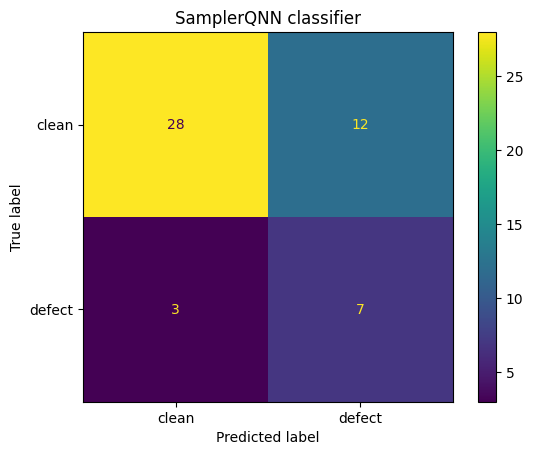

In [14]:
QNN_TRAIN_PER_CLASS = 10
QNN_REPS = 1
QNN_MAXITER = 24

X_qnn_train, y_qnn_train = balanced_subset(
    X_train_q,
    y_train,
    n_per_class=QNN_TRAIN_PER_CLASS,
)

qnn_feature_map = zz_feature_map(feature_dimension=N_QUBITS, reps=1)
qnn_ansatz = n_local(
    num_qubits=N_QUBITS,
    rotation_blocks=["ry", "rz"],
    entanglement_blocks="cz",
    entanglement="linear",
    reps=QNN_REPS,
    parameter_prefix="theta",
)

qnn_circuit = qnn_feature_map.compose(qnn_ansatz)


def parity_interpretation(measured_integer):
    """Map a measured computational-basis state to class 0 or 1 by parity."""
    return bin(measured_integer).count("1") % 2


sampler = StatevectorSampler(seed=SEED)
sampler_qnn = SamplerQNN(
    circuit=qnn_circuit,
    sampler=sampler,
    input_params=list(qnn_feature_map.parameters),
    weight_params=list(qnn_ansatz.parameters),
    interpret=parity_interpretation,
    output_shape=2,
)

np.random.seed(SEED)
initial_weights = np.random.rand(qnn_ansatz.num_parameters)
qnn_optimizer = COBYLA(maxiter=max(QNN_MAXITER, qnn_ansatz.num_parameters + 2))

qnn_classifier = NeuralNetworkClassifier(
    neural_network=sampler_qnn,
    optimizer=qnn_optimizer,
    initial_point=initial_weights,
)

qnn_classifier.fit(X_qnn_train, y_qnn_train)

evaluate_classifier("SamplerQNN classifier", qnn_classifier, X_train_q, y_train)
evaluate_classifier("SamplerQNN classifier", qnn_classifier, X_test_q, y_test)

## 11. Small Experiment Loop

Use this section for quick iteration. It tries several PCA dimensions with a classical PCA-space SVM. Once a dimension looks promising, set `N_QUBITS` above to that value and rerun the quantum sections.

In [15]:
results = []

for n_components in [2, 3, 4, 5, 6]:
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_train)
    Xte = scaler.transform(X_test)

    pca_tmp = PCA(n_components=n_components, random_state=SEED)
    Xtr = pca_tmp.fit_transform(Xtr)
    Xte = pca_tmp.transform(Xte)

    angle_tmp = MinMaxScaler(feature_range=(0, np.pi))
    Xtr = angle_tmp.fit_transform(Xtr)
    Xte = angle_tmp.transform(Xte)

    model = SVC(kernel="rbf", class_weight="balanced", random_state=SEED)
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)

    results.append({
        "n_features": n_components,
        "pca_variance": pca_tmp.explained_variance_ratio_.sum(),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "defect_f1": f1_score(y_test, pred, zero_division=0),
    })

for row in results:
    print(row)

{'n_features': 2, 'pca_variance': np.float64(0.12420901765954537), 'balanced_accuracy': 0.7375, 'defect_f1': 0.625}
{'n_features': 3, 'pca_variance': np.float64(0.18030936758441407), 'balanced_accuracy': 0.95, 'defect_f1': 0.9473684210526315}
{'n_features': 4, 'pca_variance': np.float64(0.23121942435241175), 'balanced_accuracy': 0.95, 'defect_f1': 0.9473684210526315}
{'n_features': 5, 'pca_variance': np.float64(0.27647810275666007), 'balanced_accuracy': 0.95, 'defect_f1': 0.9473684210526315}
{'n_features': 6, 'pca_variance': np.float64(0.31951118650366456), 'balanced_accuracy': 0.9, 'defect_f1': 0.8888888888888888}


## 12. Ideas for the Next Iterations

- Try `defect_rate=0.10` after you have a working pipeline.
- Try `IMAGE_SIZE=4` for faster quantum experiments, then scale back to `8`.
- Replace PCA with hand-built features such as max intensity, local contrast, or patch statistics.
- Try more feature-map reps in `zz_feature_map`, but expect slower kernels.
- Try `SPSA` instead of `COBYLA` for the QNN optimizer.
- Watch defect recall specifically. A model that predicts every sample as clean can have deceptively high ordinary accuracy.